# Collaborative Filtering Recommendation System
## User-Based & Item-Based Approaches (Rating History Only)

This notebook implements both **user-based** and **item-based** collaborative filtering using only the rating matrix — no item metadata (genres, tags) is used.

**Requirements:** `pip install pandas numpy scipy scikit-learn matplotlib`

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Load Data

In [2]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print(f"Ratings: {ratings.shape[0]:,} rows")
print(f"Unique users: {ratings['userId'].nunique():,}")
print(f"Unique movies: {ratings['movieId'].nunique():,}")
print(f"Rating range: {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Sparsity: {1 - ratings.shape[0] / (ratings['userId'].nunique() * ratings['movieId'].nunique()):.4%}")
ratings.head()

Ratings: 100,836 rows
Unique users: 610
Unique movies: 9,724
Rating range: 0.5 – 5.0
Sparsity: 98.3000%


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Exploratory Analysis of Ratings

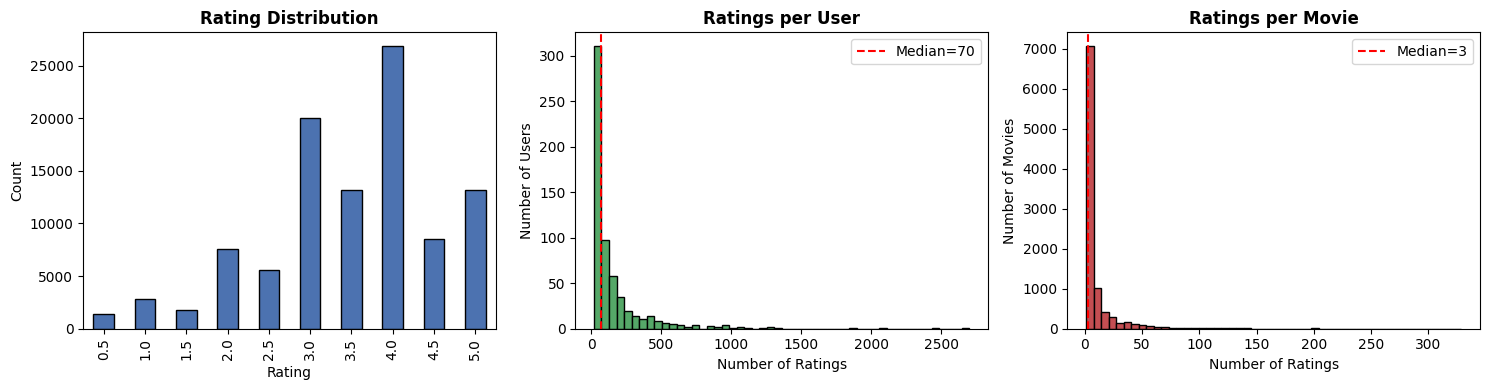

User stats  -- mean: 165.3, median: 70, max: 2698
Movie stats -- mean: 10.4, median: 3, max: 329


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0", edgecolor="black")
axes[0].set_title("Rating Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

user_counts = ratings.groupby("userId").size()
axes[1].hist(user_counts, bins=50, color="#55A868", edgecolor="black")
axes[1].set_title("Ratings per User", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Number of Users")
axes[1].axvline(user_counts.median(), color="red", linestyle="--", label=f"Median={user_counts.median():.0f}")
axes[1].legend()

movie_counts = ratings.groupby("movieId").size()
axes[2].hist(movie_counts, bins=50, color="#C44E52", edgecolor="black")
axes[2].set_title("Ratings per Movie", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Number of Ratings")
axes[2].set_ylabel("Number of Movies")
axes[2].axvline(movie_counts.median(), color="red", linestyle="--", label=f"Median={movie_counts.median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"User stats  -- mean: {user_counts.mean():.1f}, median: {user_counts.median():.0f}, max: {user_counts.max()}")
print(f"Movie stats -- mean: {movie_counts.mean():.1f}, median: {movie_counts.median():.0f}, max: {movie_counts.max()}")


## 3. Train / Test Split

In [4]:
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)
print(f"Train: {train_df.shape[0]:,} | Test: {test_df.shape[0]:,}")

Train: 80,668 | Test: 20,168


## 4. Build the User–Item Rating Matrix

In [5]:
user_item_matrix = train_df.pivot_table(index="userId", columns="movieId", values="rating")
print(f"User-Item matrix shape: {user_item_matrix.shape}")
print(f"Fill rate: {user_item_matrix.notna().sum().sum() / user_item_matrix.size:.4%}")

# Mean-center per user (subtract each user's average rating)
user_means = user_item_matrix.mean(axis=1)
user_item_centered = user_item_matrix.sub(user_means, axis=0)
user_item_filled = user_item_centered.fillna(0)


User-Item matrix shape: (610, 8983)
Fill rate: 1.4721%


## 5. User-Based Collaborative Filtering

In [11]:
class UserBasedCF:
    """User-based collaborative filtering with cosine similarity."""

    def __init__(self, rating_matrix, k=30):
        self.matrix = rating_matrix
        self.k = k
        self.user_means = rating_matrix.mean(axis=1)

        centered = rating_matrix.sub(self.user_means, axis=0).fillna(0)
        self.sim_matrix = pd.DataFrame(
            cosine_similarity(centered),
            index=rating_matrix.index,
            columns=rating_matrix.index,
        )
        sim_vals = self.sim_matrix.to_numpy(copy=True)
        np.fill_diagonal(sim_vals, 0)
        self.sim_matrix = pd.DataFrame(sim_vals, index=self.sim_matrix.index, columns=self.sim_matrix.columns)

    def predict(self, user_id, movie_id):
        """Predict rating for a (user, movie) pair."""
        if user_id not in self.matrix.index or movie_id not in self.matrix.columns:
            return self.user_means.mean()

        movie_ratings = self.matrix[movie_id].dropna()
        common_users = movie_ratings.index.intersection(self.sim_matrix.columns)

        if len(common_users) == 0:
            return self.user_means.get(user_id, self.user_means.mean())

        sims = self.sim_matrix.loc[user_id, common_users]
        top_k = sims.nlargest(self.k)
        top_k = top_k[top_k > 0]

        if top_k.empty:
            return self.user_means.get(user_id, self.user_means.mean())

        neighbor_ids = top_k.index
        neighbor_ratings = movie_ratings[neighbor_ids]
        neighbor_means = self.user_means[neighbor_ids]
        deviations = neighbor_ratings - neighbor_means

        numerator = (top_k.values * deviations.values).sum()
        denominator = top_k.abs().sum()

        pred = self.user_means[user_id] + numerator / denominator
        return float(np.clip(pred, 0.5, 5.0))

    def recommend(self, user_id, n=10):
        """Recommend top-n unseen movies for a user."""
        if user_id not in self.matrix.index:
            return []

        rated = self.matrix.loc[user_id].dropna().index
        unrated = self.matrix.columns.difference(rated)

        predictions = {}
        for mid in unrated:
            predictions[mid] = self.predict(user_id, mid)

        return sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:n]


In [12]:
print("Building User-Based CF model (k=30)...")
user_cf = UserBasedCF(user_item_matrix, k=30)
print(f"User similarity matrix: {user_cf.sim_matrix.shape}")
print("Done.")

Building User-Based CF model (k=30)...
User similarity matrix: (610, 610)
Done.


## 6. Item-Based Collaborative Filtering

In [13]:
class ItemBasedCF:
    """Item-based collaborative filtering with cosine similarity."""

    def __init__(self, rating_matrix, k=30):
        self.matrix = rating_matrix
        self.k = k
        self.user_means = rating_matrix.mean(axis=1)
        self.item_means = rating_matrix.mean(axis=0)

        centered = rating_matrix.sub(self.user_means, axis=0).fillna(0)
        self.sim_matrix = pd.DataFrame(
            cosine_similarity(centered.T),
            index=rating_matrix.columns,
            columns=rating_matrix.columns,
        )
        sim_vals = self.sim_matrix.to_numpy(copy=True)
        np.fill_diagonal(sim_vals, 0)
        self.sim_matrix = pd.DataFrame(sim_vals, index=self.sim_matrix.index, columns=self.sim_matrix.columns)

    def predict(self, user_id, movie_id):
        """Predict rating for a (user, movie) pair."""
        if user_id not in self.matrix.index or movie_id not in self.matrix.columns:
            return self.user_means.mean()

        user_ratings = self.matrix.loc[user_id].dropna()
        rated_movies = user_ratings.index.intersection(self.sim_matrix.columns)

        if len(rated_movies) == 0:
            return self.user_means.get(user_id, self.user_means.mean())

        if movie_id not in self.sim_matrix.index:
            return self.user_means.get(user_id, self.user_means.mean())

        sims = self.sim_matrix.loc[movie_id, rated_movies]
        top_k = sims.nlargest(self.k)
        top_k = top_k[top_k > 0]

        if top_k.empty:
            return self.user_means.get(user_id, self.user_means.mean())

        neighbor_ids = top_k.index
        neighbor_ratings = user_ratings[neighbor_ids]

        numerator = (top_k.values * neighbor_ratings.values).sum()
        denominator = top_k.abs().sum()

        pred = numerator / denominator
        return float(np.clip(pred, 0.5, 5.0))

    def recommend(self, user_id, n=10):
        """Recommend top-n unseen movies for a user."""
        if user_id not in self.matrix.index:
            return []

        rated = self.matrix.loc[user_id].dropna().index
        unrated = self.matrix.columns.difference(rated)

        predictions = {}
        for mid in unrated:
            predictions[mid] = self.predict(user_id, mid)

        return sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:n]


In [14]:
print("Building Item-Based CF model (k=30)...")
item_cf = ItemBasedCF(user_item_matrix, k=30)
print(f"Item similarity matrix: {item_cf.sim_matrix.shape}")
print("Done.")

Building Item-Based CF model (k=30)...
Item similarity matrix: (8983, 8983)
Done.


## 7. Evaluation on Test Set

In [15]:
def evaluate_model(model, test_data, name, sample_size=5000):
    """Evaluate a CF model on test data using RMSE and MAE."""
    test_sample = test_data.sample(n=min(sample_size, len(test_data)), random_state=42)

    actuals = []
    predictions = []

    for _, row in test_sample.iterrows():
        pred = model.predict(int(row["userId"]), int(row["movieId"]))
        actuals.append(row["rating"])
        predictions.append(pred)

    act_arr = np.array(actuals)
    pred_arr = np.array(predictions)

    rmse = np.sqrt(mean_squared_error(act_arr, pred_arr))
    mae = mean_absolute_error(act_arr, pred_arr)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Test samples evaluated: {len(act_arr):,}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"{'='*45}")

    return act_arr, pred_arr, rmse, mae


In [16]:
print("Evaluating User-Based CF on test set (sampling 5,000 ratings)...")
u_act, u_pred, u_rmse, u_mae = evaluate_model(user_cf, test_df, "User-Based CF")

print("\nEvaluating Item-Based CF on test set (sampling 5,000 ratings)...")
i_act, i_pred, i_rmse, i_mae = evaluate_model(item_cf, test_df, "Item-Based CF")


Evaluating User-Based CF on test set (sampling 5,000 ratings)...

  User-Based CF
  Test samples evaluated: 5,000
  RMSE: 0.8966
  MAE:  0.6820

Evaluating Item-Based CF on test set (sampling 5,000 ratings)...

  Item-Based CF
  Test samples evaluated: 5,000
  RMSE: 0.8799
  MAE:  0.6683


## 8. Comparison Visualisation

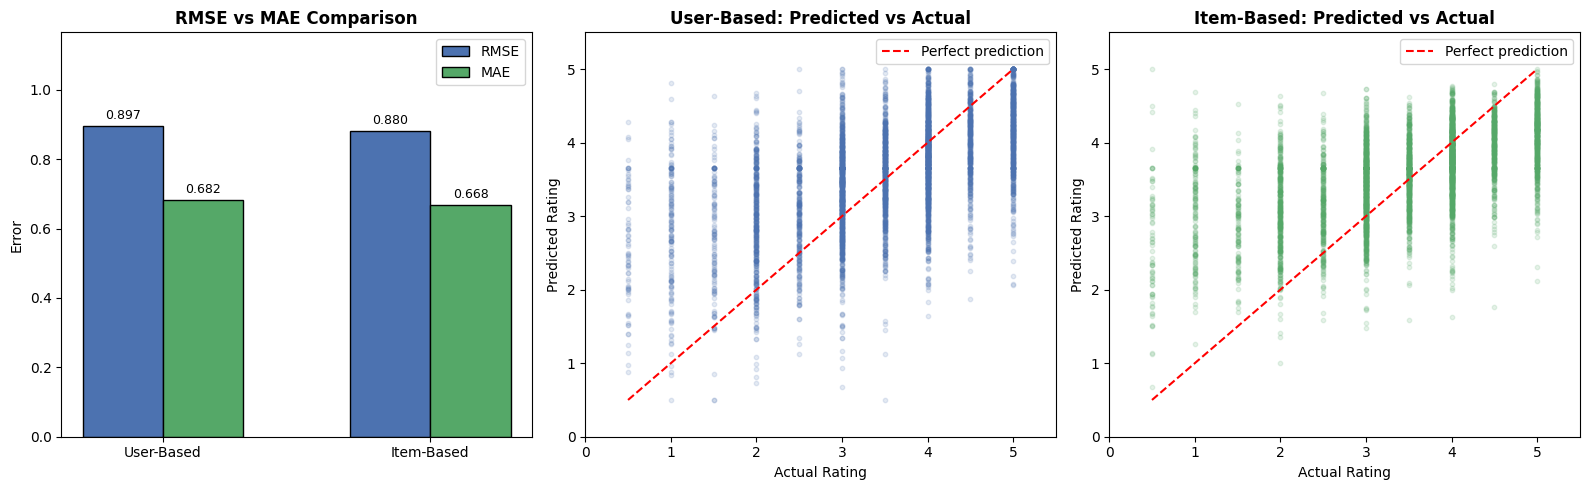

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = ["User-Based", "Item-Based"]
rmses = [u_rmse, i_rmse]
maes = [u_mae, i_mae]
x = np.arange(len(methods))
w = 0.3
axes[0].bar(x - w / 2, rmses, w, label="RMSE", color="#4C72B0", edgecolor="black")
axes[0].bar(x + w / 2, maes, w, label="MAE", color="#55A868", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel("Error")
axes[0].set_title("RMSE vs MAE Comparison", fontweight="bold")
axes[0].legend()
axes[0].set_ylim(0, max(rmses + maes) * 1.3)
for i in range(len(methods)):
    axes[0].text(x[i] - w / 2, rmses[i] + 0.02, f"{rmses[i]:.3f}", ha="center", fontsize=9)
    axes[0].text(x[i] + w / 2, maes[i] + 0.02, f"{maes[i]:.3f}", ha="center", fontsize=9)

axes[1].scatter(u_act, u_pred, alpha=0.15, s=10, color="#4C72B0")
axes[1].plot([0.5, 5], [0.5, 5], "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_xlabel("Actual Rating")
axes[1].set_ylabel("Predicted Rating")
axes[1].set_title("User-Based: Predicted vs Actual", fontweight="bold")
axes[1].legend()
axes[1].set_xlim(0, 5.5)
axes[1].set_ylim(0, 5.5)

axes[2].scatter(i_act, i_pred, alpha=0.15, s=10, color="#55A868")
axes[2].plot([0.5, 5], [0.5, 5], "r--", linewidth=1.5, label="Perfect prediction")
axes[2].set_xlabel("Actual Rating")
axes[2].set_ylabel("Predicted Rating")
axes[2].set_title("Item-Based: Predicted vs Actual", fontweight="bold")
axes[2].legend()
axes[2].set_xlim(0, 5.5)
axes[2].set_ylim(0, 5.5)

plt.tight_layout()
plt.show()


## 9. Error Distribution Analysis

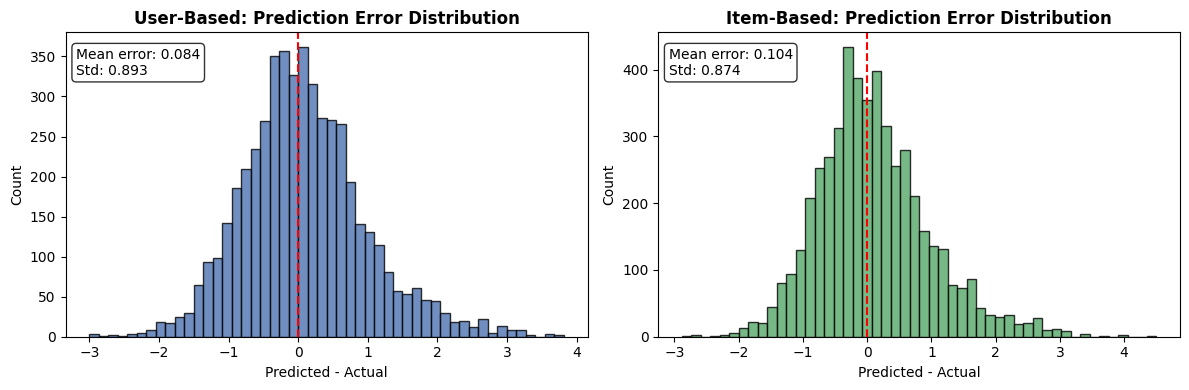

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

u_errors = u_pred - u_act
i_errors = i_pred - i_act

axes[0].hist(u_errors, bins=50, color="#4C72B0", edgecolor="black", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("User-Based: Prediction Error Distribution", fontweight="bold")
axes[0].set_xlabel("Predicted - Actual")
axes[0].set_ylabel("Count")
axes[0].text(
    0.02, 0.95,
    f"Mean error: {u_errors.mean():.3f}\nStd: {u_errors.std():.3f}",
    transform=axes[0].transAxes, verticalalignment="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

axes[1].hist(i_errors, bins=50, color="#55A868", edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Item-Based: Prediction Error Distribution", fontweight="bold")
axes[1].set_xlabel("Predicted - Actual")
axes[1].set_ylabel("Count")
axes[1].text(
    0.02, 0.95,
    f"Mean error: {i_errors.mean():.3f}\nStd: {i_errors.std():.3f}",
    transform=axes[1].transAxes, verticalalignment="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()


## 10. Example Recommendations

In [19]:
# Pick a user with a decent number of ratings
sample_user = train_df.groupby("userId").size()
sample_user = sample_user[sample_user.between(50, 200)].sample(1, random_state=42).index[0]

print(f"=== Recommendations for User {sample_user} ===")
print(f"(This user rated {train_df[train_df['userId'] == sample_user].shape[0]} movies in training set)\n")

user_top = train_df[train_df["userId"] == sample_user].nlargest(5, "rating")
user_top = user_top.merge(movies[["movieId", "title"]], on="movieId")
print("Their top-rated movies:")
for _, r in user_top.iterrows():
    print(f"  * {r['rating']:.1f}  {r['title']}")

print(f"\n--- User-Based CF Top-10 ---")
u_recs = user_cf.recommend(sample_user, n=10)
for rank, (mid, score) in enumerate(u_recs, 1):
    title = movies.loc[movies["movieId"] == mid, "title"].values
    title = title[0] if len(title) > 0 else f"Movie {mid}"
    print(f"  {rank:2d}. {title:<50s}  (predicted: {score:.2f})")

print(f"\n--- Item-Based CF Top-10 ---")
i_recs = item_cf.recommend(sample_user, n=10)
for rank, (mid, score) in enumerate(i_recs, 1):
    title = movies.loc[movies["movieId"] == mid, "title"].values
    title = title[0] if len(title) > 0 else f"Movie {mid}"
    print(f"  {rank:2d}. {title:<50s}  (predicted: {score:.2f})")


=== Recommendations for User 22 ===
(This user rated 100 movies in training set)

Their top-rated movies:
  * 5.0  One Flew Over the Cuckoo's Nest (1975)
  * 5.0  Midnight Cowboy (1969)
  * 5.0  Forrest Gump (1994)
  * 5.0  Blade Runner (1982)
  * 5.0  Shawshank Redemption, The (1994)

--- User-Based CF Top-10 ---
   1. Hangar 18 (1980)                                    (predicted: 5.00)
   2. Galaxy of Terror (Quest) (1981)                     (predicted: 5.00)
   3. Come and See (Idi i smotri) (1985)                  (predicted: 5.00)
   4. Alien Contamination (1980)                          (predicted: 5.00)
   5. Bossa Nova (2000)                                   (predicted: 4.94)
   6. Frank (2014)                                        (predicted: 4.91)
   7. Paterson                                            (predicted: 4.91)
   8. The Big Bus (1976)                                  (predicted: 4.79)
   9. Seve (2014)                                         (predicted: 4.79)


## 11. Similarity Heatmap (Top Users)

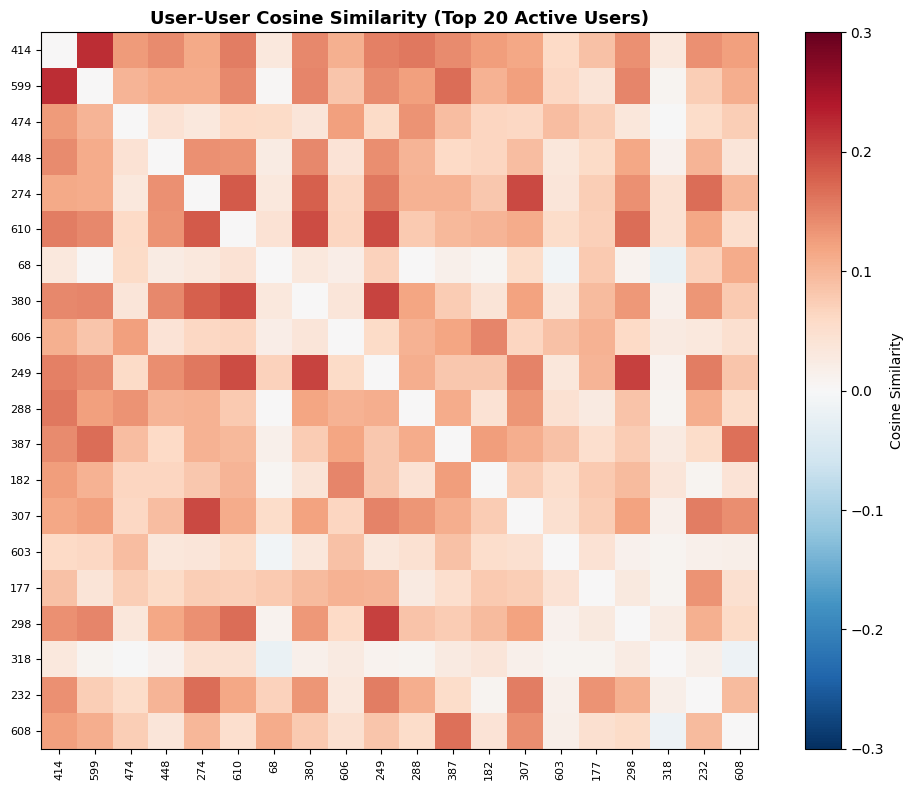

In [20]:
top_users = train_df.groupby("userId").size().nlargest(20).index
sub_sim = user_cf.sim_matrix.loc[top_users, top_users]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sub_sim.values, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(top_users)))
ax.set_yticks(range(len(top_users)))
ax.set_xticklabels(top_users, rotation=90, fontsize=8)
ax.set_yticklabels(top_users, fontsize=8)
ax.set_title("User-User Cosine Similarity (Top 20 Active Users)", fontweight="bold", fontsize=13)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
plt.tight_layout()
plt.show()


## 12. Impact of Neighbourhood Size (k)

Testing k=5...
Testing k=10...
Testing k=20...


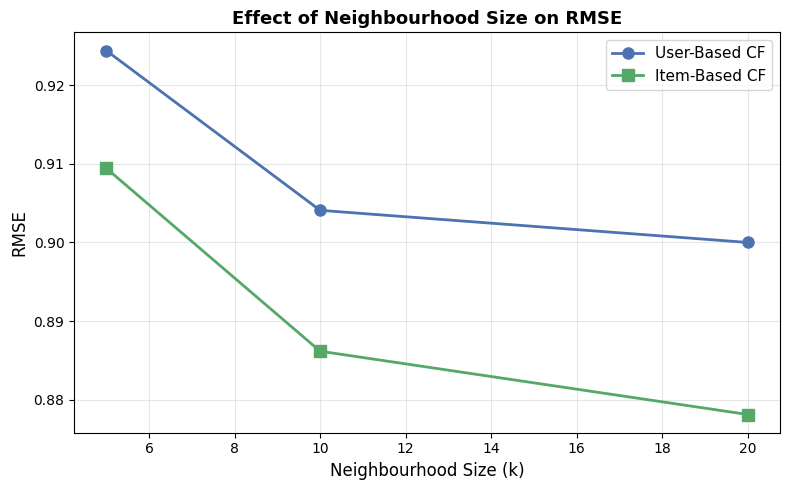

  k= 5  |  User RMSE=0.9244  |  Item RMSE=0.9094
  k=10  |  User RMSE=0.9041  |  Item RMSE=0.8862
  k=20  |  User RMSE=0.9000  |  Item RMSE=0.8781


In [22]:
ks = [5, 10, 20]
u_rmses_k = []
i_rmses_k = []

test_sample_k = test_df.sample(n=2000, random_state=42)

for k_val in ks:
    print(f"Testing k={k_val}...")
    ucf = UserBasedCF(user_item_matrix, k=k_val)
    preds = [ucf.predict(int(r["userId"]), int(r["movieId"])) for _, r in test_sample_k.iterrows()]
    u_rmses_k.append(np.sqrt(mean_squared_error(test_sample_k["rating"], preds)))

    icf = ItemBasedCF(user_item_matrix, k=k_val)
    preds = [icf.predict(int(r["userId"]), int(r["movieId"])) for _, r in test_sample_k.iterrows()]
    i_rmses_k.append(np.sqrt(mean_squared_error(test_sample_k["rating"], preds)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, u_rmses_k, "o-", color="#4C72B0", linewidth=2, markersize=8, label="User-Based CF")
ax.plot(ks, i_rmses_k, "s-", color="#55A868", linewidth=2, markersize=8, label="Item-Based CF")
ax.set_xlabel("Neighbourhood Size (k)", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("Effect of Neighbourhood Size on RMSE", fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k_val, ur, ir in zip(ks, u_rmses_k, i_rmses_k):
    print(f"  k={k_val:2d}  |  User RMSE={ur:.4f}  |  Item RMSE={ir:.4f}")


## 13. Summary

**What was implemented:**
- **User-Based CF**: Finds users with similar taste profiles (cosine similarity on mean-centred ratings), then predicts a target rating as the weighted average of neighbour deviations from their means.
- **Item-Based CF**: Finds movies that received similar rating patterns across users, then predicts from the weighted average of the target user’s ratings on similar items.

**Key design choices:**
- Only the rating matrix is used — no genre, tag, or other metadata.
- Ratings are mean-centred per user before computing similarity to remove user bias.
- Neighbourhood size `k` is tuneable; the sensitivity analysis above shows its effect.
- Predictions are clipped to [0.5, 5.0] to stay within the valid rating range.
- Cold-start users/items fall back to global or user mean.

**Evaluation:**
- 80/20 train/test split, evaluated on a 5,000-rating sample.
- Both RMSE and MAE reported, plus predicted-vs-actual scatter and error histograms.